In [4]:
from lorenzo_utils import *
from visualization_utils import *
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

graph_path = DATA_DIR + 'Centrality/Centrality_climate_19.graphml'
G = load_graph(graph_path)



c:\Users\maria\Desktop\Analisi e visualizzazione reti complesse\AVRC_FinnishTwittersphereProject\Maru\lorenzo_utils.py:24: RuntimeWarning: Could not add vertex ids, there is already an 'id' vertex attribute. Location: src/io/graphml.c:434
  return ig.Graph.Read_GraphML(filename)


# Statistica del network

In [5]:
def network_statistics(G):
    N = G.vcount()
    L = G.ecount()
    rho = G.density()
    avg_degree = 2 * L / N
    avg_clustering = G.transitivity_avglocal_undirected() # coefficiente di clustering medio
    diametro = G.diameter() # diametro del grafo


    return {
        "Numero di Nodi": N,
        "Numero di Archi": L,
        "Densità del Grafo": rho,
        "Grado Medio": avg_degree,
        "Clustering Medio": avg_clustering,
        "Diametro": diametro 
    }


In [6]:
def print_network_statistics(G):
    stat = network_statistics(G)
    print("        STATISTICHE DEL NETWORK        ")
    print("-"*40)
    for key, value in stat.items():
        print(f"{key}: {value}")
        
    print("-"*40)


In [7]:
print_network_statistics(G)

        STATISTICHE DEL NETWORK        
----------------------------------------
Numero di Nodi: 16639
Numero di Archi: 50605
Densità del Grafo: 0.0003655906525712596
Grado Medio: 6.082697277480618
Clustering Medio: 0.17544907339858107
Diametro: 13
----------------------------------------


In [63]:
nodi_A = G.vs.select(group="A")
G_A = G.subgraph(nodi_A)
nodi_B = G.vs.select(group="B")
G_B = G.subgraph(nodi_B)

stats_A = network_statistics(G_A)
stats_B = network_statistics(G_B)

print("SOTTOGRAFO A")
print_network_statistics(G_A)
print("\nSOTTOGRAFO B")
print_network_statistics(G_B)

SOTTOGRAFO A
        STATISTICHE DEL NETWORK        
----------------------------------------
Numero di Nodi: 7409
Numero di Archi: 28384
Densità del Grafo: 0.0010342916661686635
Grado Medio: 7.6620326629774596
Clustering Medio: 0.2572179272650303
Diametro: 12
----------------------------------------

SOTTOGRAFO B
        STATISTICHE DEL NETWORK        
----------------------------------------
Numero di Nodi: 9230
Numero di Archi: 17487
Densità del Grafo: 0.00041057165064618605
Grado Medio: 3.789165763813651
Clustering Medio: 0.12504484957300033
Diametro: 14
----------------------------------------


# Calcolo delle metriche e aggiornamento su file

In [3]:
COMPUTE_CENTRALITY = False
if COMPUTE_CENTRALITY:
    from sys import stdout
    for graph_file in GRAPH_FILENAMES:
        print('loading:', graph_file)
        stdout.flush()
        G = load_graph(DATA_DIR + graph_file)
        load_all_centralities(G, dumpfile=DATA_DIR+'Centrality/Centrality_'+graph_file)
        print('saved centrality')

# CCDF (Complementary cumulative distribution)

In [ ]:
def plot_ccdf(G: ig.Graph, metric: str='degree', log: bool=True):
    values = np.array(G.vs[metric])
    k_values, ccdf = compute_ccdf(values)
    kA_values, ccdfA = compute_ccdf(values[[group == 'A' for group in G.vs['group']]])
    kB_values, ccdfB = compute_ccdf(values[[group == 'B' for group in G.vs['group']]])

    fig, ax = plt.subplots(figsize=FIGSIZE, sharex=True, layout='tight')
    ax.plot(k_values, ccdf, marker='.', linewidth='2', markersize='0.3', color = cmap(0), label='Tot')
    ax.plot(kA_values, ccdfA, marker='.', linewidth='2', markersize='0.3', color = cmap(1), label='A')
    ax.plot(kB_values, ccdfB, marker='.', linewidth='2', markersize='0.3', color = cmap(2), label='B')
    ax.set_title(metric + ' complementary cumulative distribution')
    ax.set_xlabel(metric)
    ax.set_ylabel('ccdf')
    fig.legend(frameon=False, bbox_to_anchor=(0.99,0.9), loc='upper right')
    if log:
        ax.set_xscale('log')
        ax.set_yscale('log')
    plt.show()    
    plt.close(fig)   

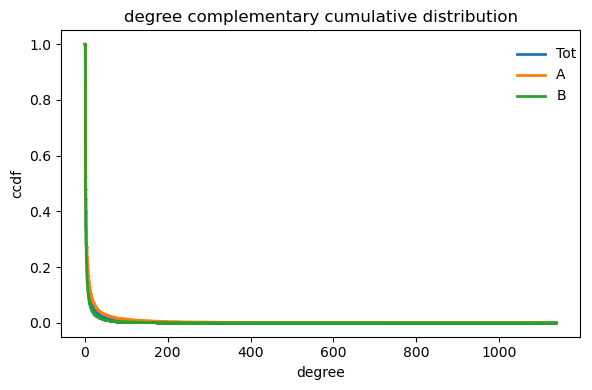

In [15]:
plot_ccdf(G, 'degree', log=False)

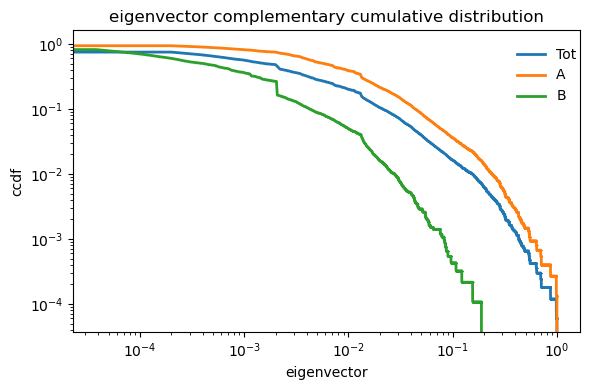

In [16]:
plot_ccdf(G, 'eigenvector', log=True)

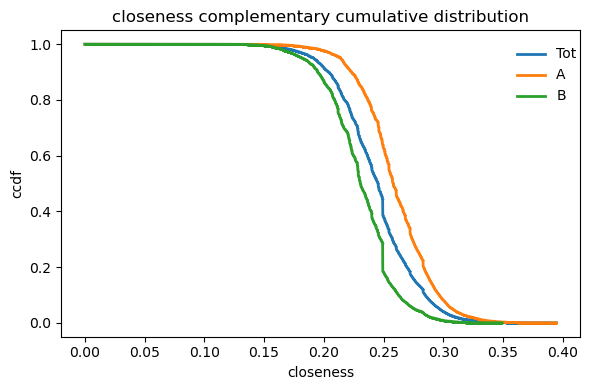

In [17]:
plot_ccdf(G, 'closeness', log=False)

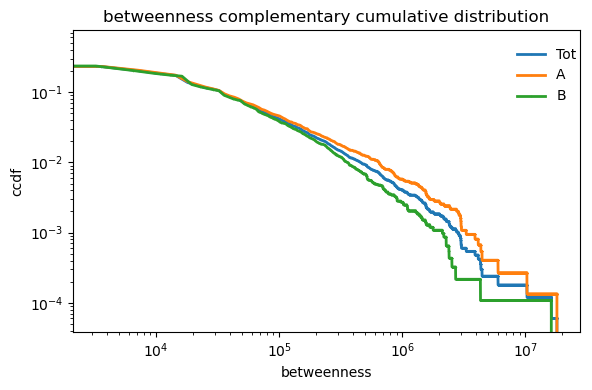

In [18]:
plot_ccdf(G, 'betweenness', log=True)

# Scatter plot

In [ ]:
def plot_metric_vs_metric(G, metric_x, metric_y):
    fig, ax = plt.subplots(figsize=FIGSIZE, sharex=True, layout='tight')
    ax.scatter(G.vs[metric_x], G.vs[metric_y], s=0.3, color=cmap(0))
    ax.set_title(f'{metric_y} vs {metric_x}')
    ax.set_xlabel(metric_x)
    ax.set_ylabel(metric_y)
    ax.set_xscale('log')
    ax.set_yscale('log')
    plt.show()
    plt.close(fig)

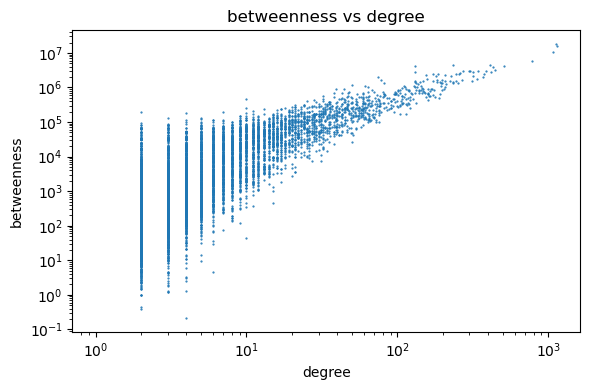

In [22]:
plot_metric_vs_metric(G, 'degree', 'betweenness')

# Distribuzioni di misure di centralità

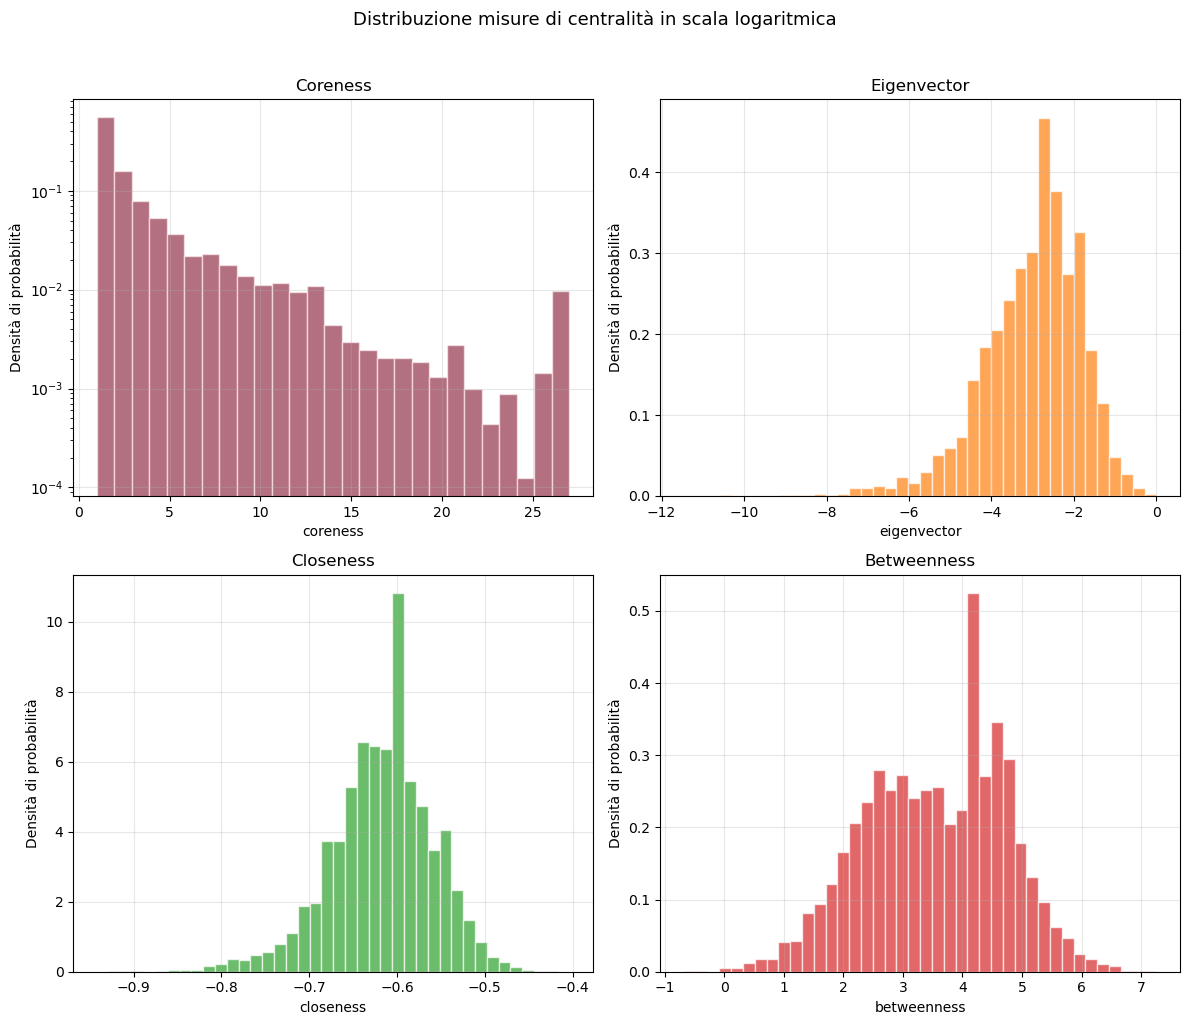

In [ ]:
metrics = ['coreness', 'eigenvector', 'closeness', 'betweenness']
fig, axes = plt.subplots(2, 2, figsize=FIGSIZE_LARGE, layout='tight')
colors = [cmap(i) for i in range(len(metrics))]

for ax, m, color in zip(axes.flat, metrics, colors):
    
    values = np.array(G.vs[m], dtype=float)
    values = values[values > 0]

    if m == 'coreness':
        ax.hist(values, bins=27, density=True,
                color=cmap(0), alpha=0.5, edgecolor='white', label='A')
        ax.hist(values, bins=27, density=True,
                color=cmap(3), alpha=0.5, edgecolor='white', label='B')
        ax.set_yscale('log')
    else:    
        ax.hist(np.log10(values), bins=40, density=True,
                color=color, alpha=0.7, edgecolor='white')
    ax.set_title(m.capitalize())
    ax.set_xlabel(m)
    ax.set_ylabel("Densità di probabilità" )
    ax.grid(alpha=0.3)

fig.suptitle("Distribuzione misure di centralità in scala logaritmica", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
plt.close(fig)

Domanda:
sono gli stessi nodi a generare i picchi nei vari grafici?

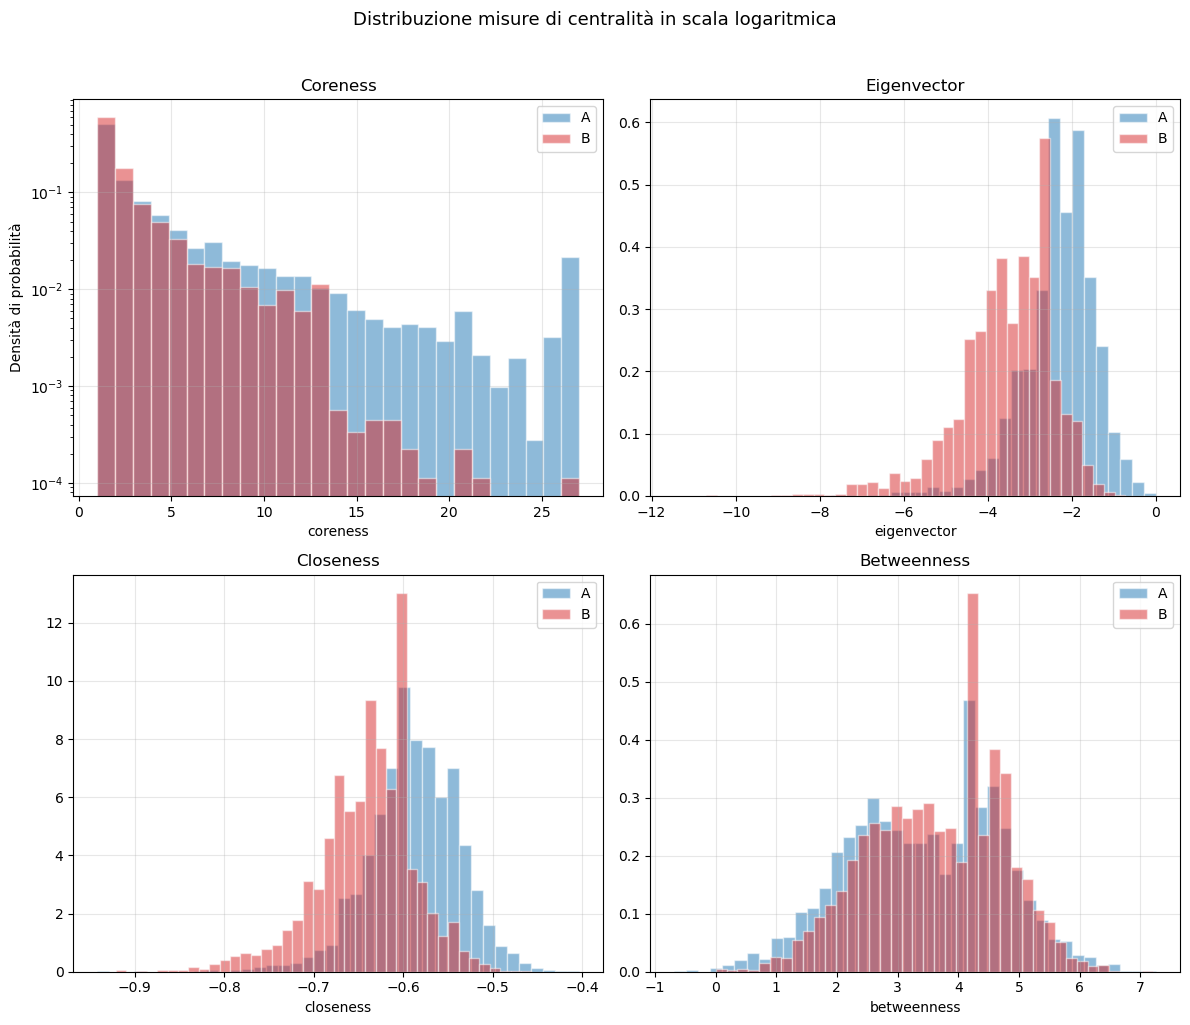

In [ ]:
metrics = ['coreness', 'eigenvector', 'closeness', 'betweenness']
fig, axes = plt.subplots(2, 2, figsize=FIGSIZE_LARGE)


for ax, m in zip(axes.flat, metrics):
    values = np.array(G.vs[m], dtype=float)

    valuesA = np.array(values[[group == 'A' for group in G.vs['group']]])
    valuesB = np.array(values[[group == 'B' for group in G.vs['group']]])
    valuesA = valuesA[valuesA > 0]
    valuesB = valuesB[valuesB > 0]

    if m == 'coreness':  # coreness è già in scala discreta, non ha senso logaritmizzarla
        ax.hist(valuesA, bins=27, density=True,
                color=color_group['A'], alpha=0.5, edgecolor='white', label='A')
        ax.hist(valuesB, bins=27, density=True,
                color=color_group['B'], alpha=0.5, edgecolor='white', label='B')
        ax.set_yscale('log')

    else:
        ax.hist(np.log10(valuesA), bins=40, density=True,
                color=color_group['A'], alpha=0.5, edgecolor='white', label='A')
        ax.hist(np.log10(valuesB), bins=40, density=True,
                color=color_group['B'], alpha=0.5, edgecolor='white', label='B')
    ax.set_title(m.capitalize())
    ax.set_xlabel(m)
    ax.set_ylabel("Densità di probabilità" if ax == axes[0, 0] else "")
    ax.grid(alpha=0.3)
    ax.legend()

fig.savefig("centralities.png")
fig.suptitle("Distribuzione misure di centralità in scala logaritmica", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
plt.close(fig)

- **CORENESS** 
Il gruppo A domina i k-core alti (coreness 10–27), mentre B è quasi assente oltre il 15. Questo indica che A forma un nucleo densamente interconnesso, un "inner circle" di utenti che si ritwittano a vicenda intensamente. B invece è più periferico, con molti nodi a basso coreness. È un segnale classico di **echo chamber asimmetrica**: A ha una comunità più coesa e organizzata.
- **EIGENVECTOR**
B ha la distribuzione spostata verso sinistra (valori più negativi = centralità più bassa), A verso destra. Significa che i nodi di A sono connessi ad altri nodi influenti, mentre B ha nodi influenti più isolati o connessi a nodi periferici. In un grafo di retweet politico, questo può indicare che le figure chiave di A amplificano reciprocamente il loro messaggio più efficacemente.
- **CLOSENESS**
A è spostato verso destra (valori meno negativi = closeness più alta). I nodi di A raggiungono il resto del grafo in meno passi: sono meglio posizionati per diffondere informazioni a tutto il network. B ha closeness più bassa e più dispersa, suggerendo una struttura più frammentata.
- **BETWEENNESS**
Qui la differenza è più sottile, ma A tende ad avere betweenness leggermente più alta e con coda più lunga verso destra. Ci sono nodi di A che fungono da **broker o ponti** nella rete. Interessante: se ci sono nodi B con alta betweenness, potrebbero essere utenti che "attraversano" le due bolle (cross-cutting), vale la pena identificarli.

## Degree distribution

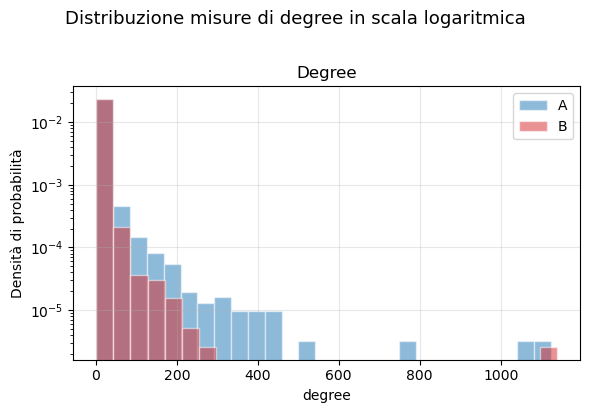

In [ ]:
m = 'degree'
fig, ax = plt.subplots(figsize=FIGSIZE)

values = np.array(G.vs[m], dtype=float)
valuesA = np.array(values[[group == 'A' for group in G.vs['group']]])
valuesB = np.array(values[[group == 'B' for group in G.vs['group']]])
valuesA = valuesA[valuesA > 0]
valuesB = valuesB[valuesB > 0]


ax.hist(valuesA, bins=27, density=True,
        color=color_group['A'], alpha=0.5, edgecolor='white', label='A')
ax.hist(valuesB, bins=27, density=True,
        color=color_group['B'], alpha=0.5, edgecolor='white', label='B')
ax.set_yscale('log')

ax.set_title(m.capitalize())
ax.set_xlabel(m)
ax.set_ylabel("Densità di probabilità")
ax.grid(alpha=0.3)
ax.legend()

fig.suptitle(f"Distribuzione misure di {m} in scala logaritmica", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
plt.close(fig)

# Coreness

In [28]:
G.vs['coreness'] = G.coreness()

In [29]:
max_coreness = max(G.vs['coreness'])
nodes_in_max_core = G.vs.select(coreness_ge=max_coreness)
main_core = G.subgraph(nodes_in_max_core)
print(f"Il core massimo ha k = {max_coreness} e contiene {main_core.vcount()} nodi.")

Il core massimo ha k = 27 e contiene 155 nodi.


In [33]:
def plot_subgraph_core(G, K_core):
    nodes_in_core = G.vs.select(coreness_ge=K_core)
    subgraph_core = G.subgraph(nodes_in_core)
    print(f"Il core ha k = {K_core} e contiene {subgraph_core.vcount()} nodi.")
    plot_group_AB(subgraph_core, save=False, only_periphery=False, niter=None)

    plt.show()
    plt.close(fig) 

Il core ha k = 10 e contiene 1223 nodi.
Gruppi trovati: ['A', 'B']


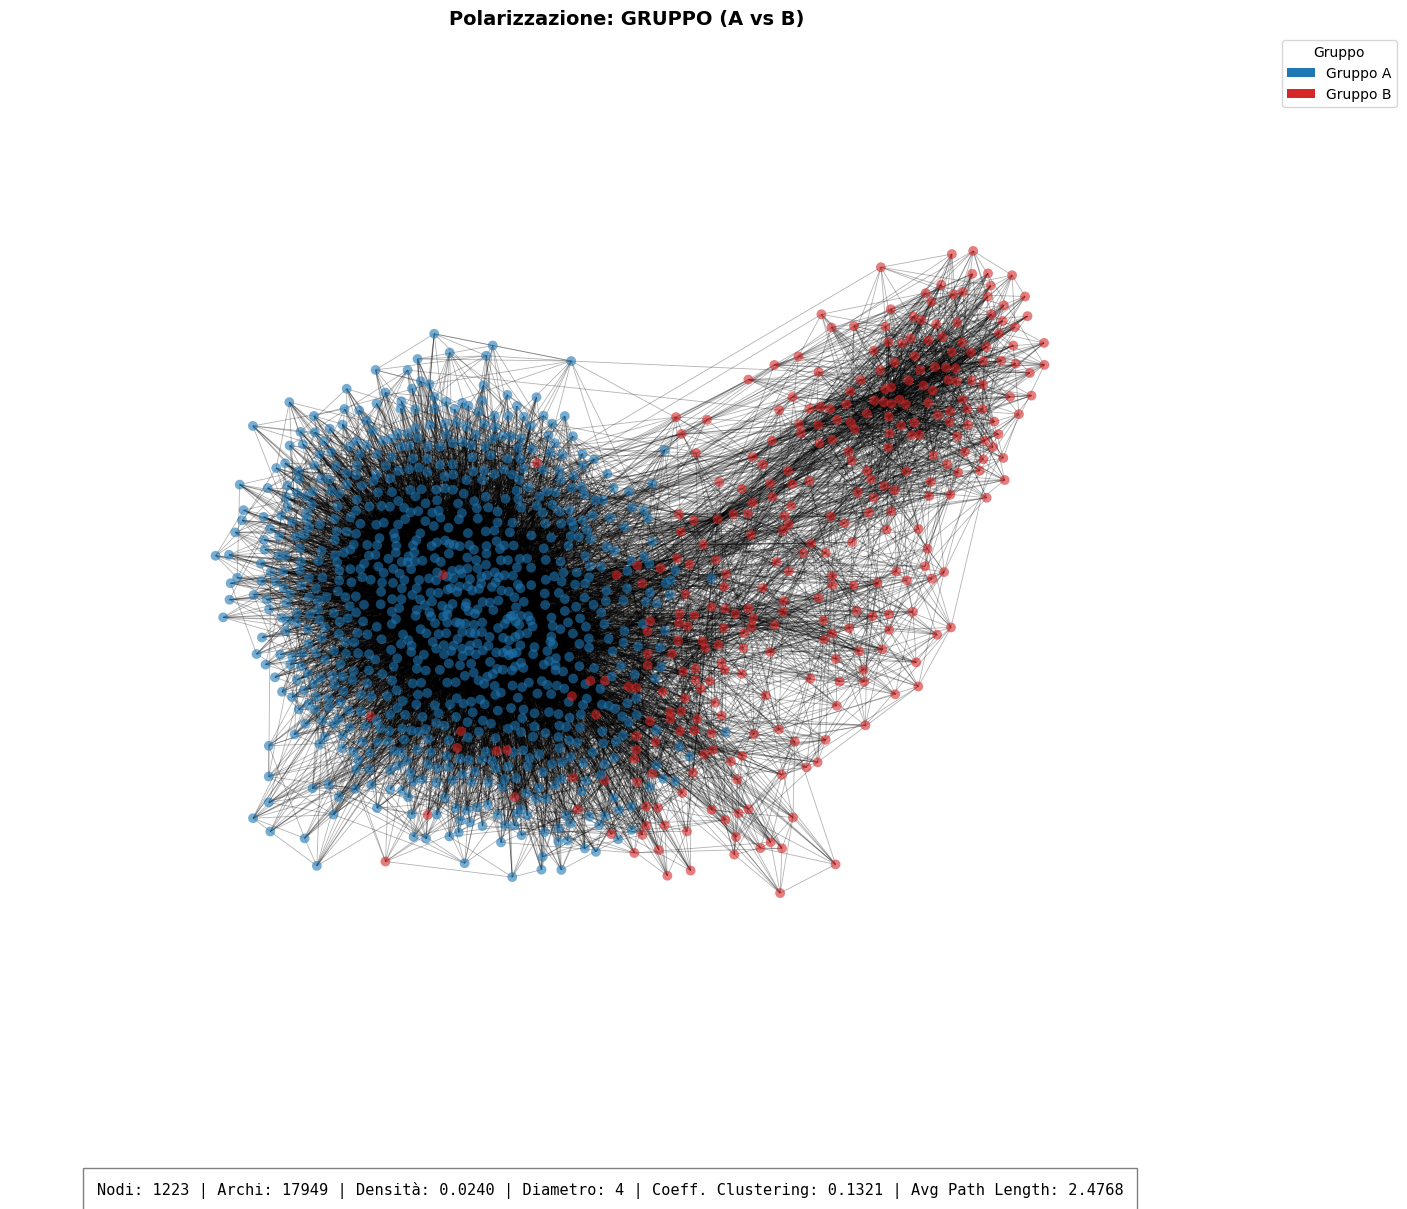

In [34]:
plot_subgraph_core(G, K_core=10)

Il core ha k = 27 e contiene 155 nodi.
Gruppi trovati: ['A', 'B']


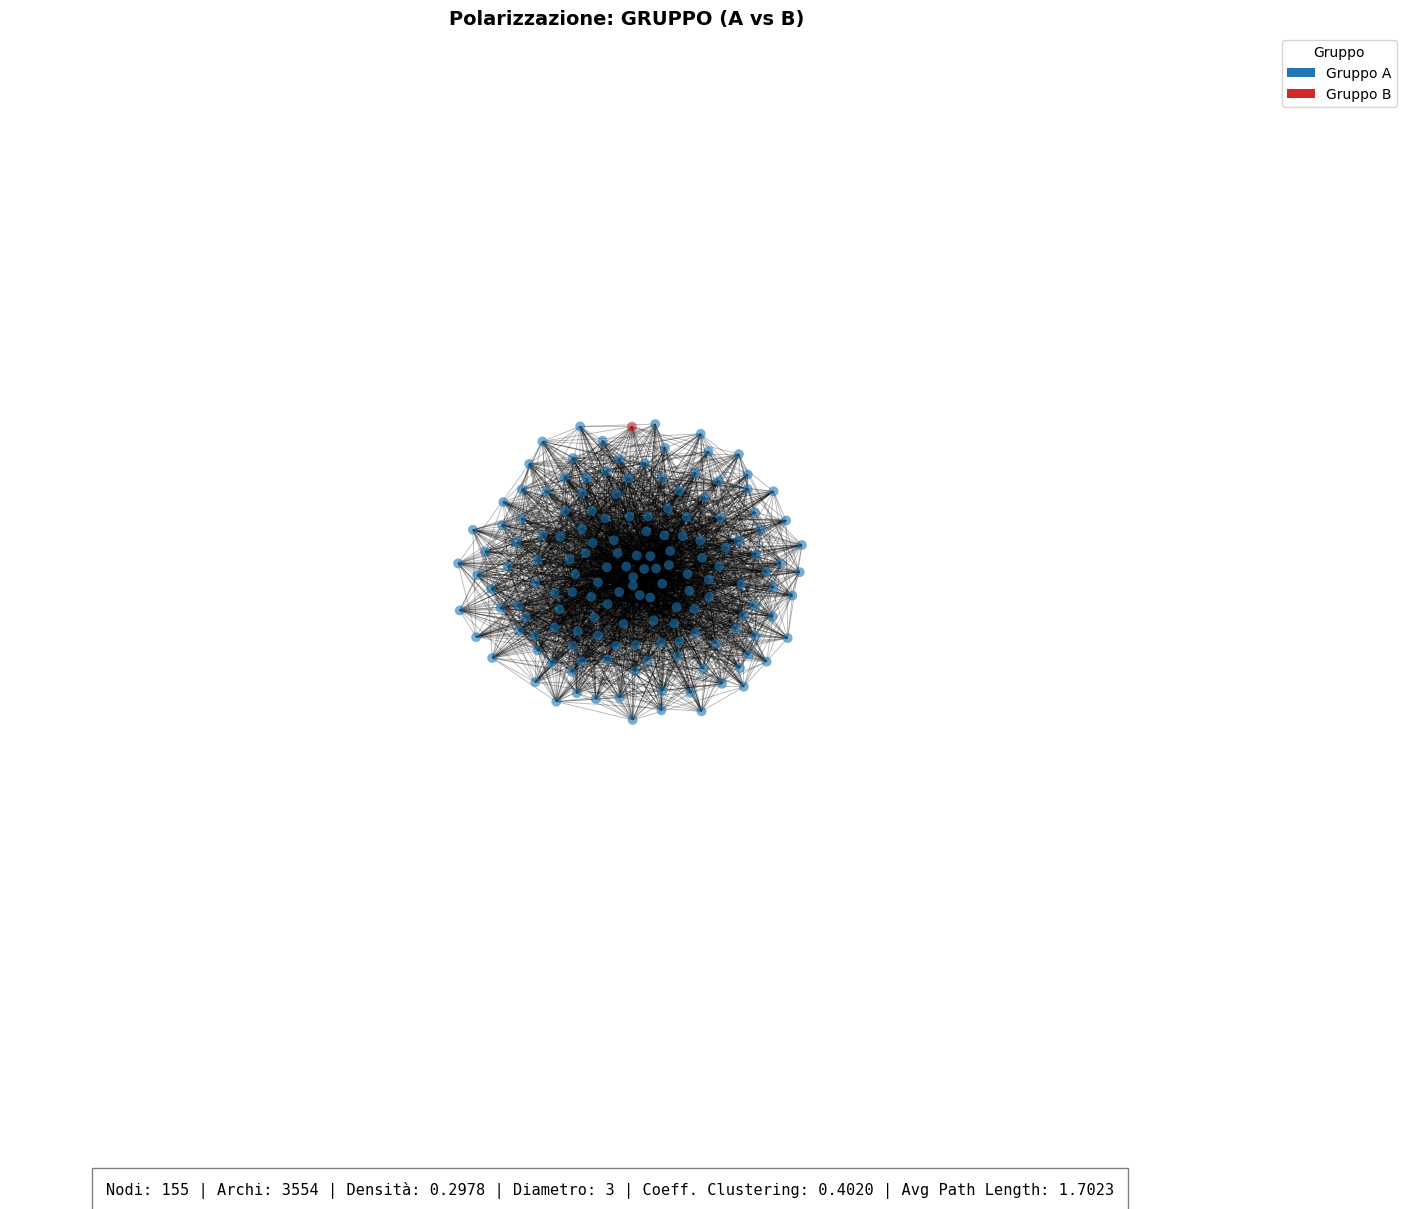

In [35]:
plot_subgraph_core(G, K_core=max_coreness)

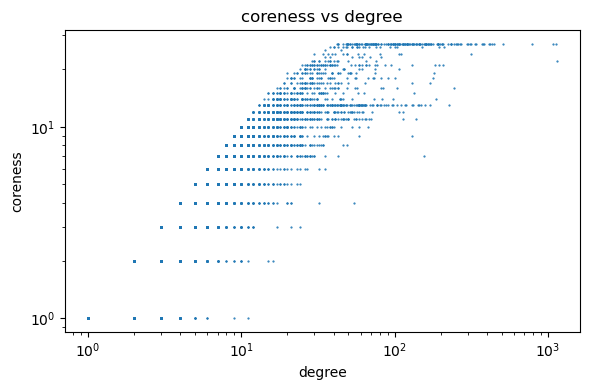

In [36]:
# coreness vs degree
plot_metric_vs_metric(G, 'degree', 'coreness')

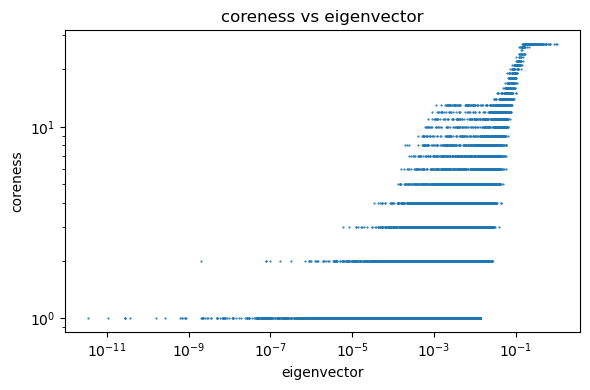

In [37]:
# coreness vs eigenvector
plot_metric_vs_metric(G, 'eigenvector', 'coreness')

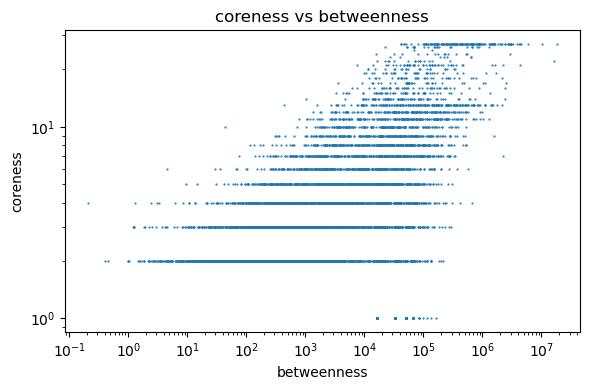

In [48]:
# coreness vs betweenness
plot_metric_vs_metric(G, 'betweenness', 'coreness')

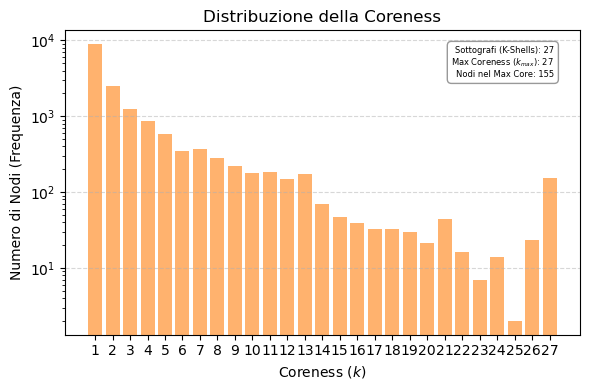

In [ ]:
from collections import Counter
# Conta le frequenze di ciascun livello di k
counts = Counter(G.vs['coreness'])
ks = sorted(counts.keys())
frequencies = [counts[k] for k in ks]

fig, ax = plt.subplots(figsize=FIGSIZE, sharex=True, layout='tight')

# Grafico a barre
ax.bar(ks, frequencies, color=cmap(1), alpha=0.6)

# Ottimizzazione assi e griglia
ax.set_xlabel("Coreness ($k$)")
ax.set_ylabel("Numero di Nodi (Frequenza)")
ax.set_title("Distribuzione della Coreness")

# Usa scala logaritmica sull'asse Y se la periferia schiaccia troppo il grafico
ax.set_yscale('log') 

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_xticks(ks if len(ks) < 30 else np.arange(min(ks), max(ks)+1, max(ks)//10))

# Box informativo con metriche chiave
info_text = f"Sottografi (K-Shells): {len(ks)}\nMax Coreness ($k_{{max}}$): {max(ks)}\nNodi nel Max Core: {counts[max(ks)]}"
ax.text(0.95, 0.95, info_text, transform=ax.transAxes, fontsize=6,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()

plt.show()

plt.close(fig)

# Spearman rank

In [43]:
from scipy.stats import spearmanr

metrics = ['degree', 'eigenvector', 'closeness', 'betweenness']
df = pd.DataFrame({m: G.vs[m] for m in metrics})

# --- Matrice di correlazione di Spearman ---
corr_matrix, p_matrix = spearmanr(df)
corr_df = pd.DataFrame(corr_matrix, index=metrics, columns=metrics)

print(corr_df.round(3))

             degree  eigenvector  closeness  betweenness
degree        1.000        0.549      0.596        0.943
eigenvector   0.549        1.000      0.979        0.470
closeness     0.596        0.979      1.000        0.522
betweenness   0.943        0.470      0.522        1.000


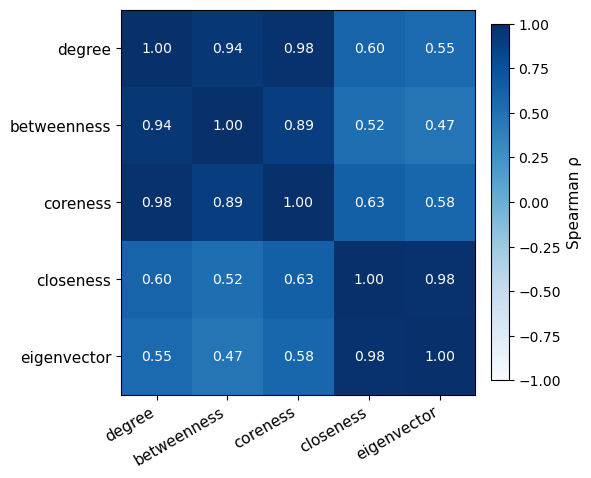

In [ ]:
from scipy.stats import spearmanr
import matplotlib.colors as mcolors


# --- 2. Calcola le centralità ---
centralities = {
    'degree':      G.vs['degree'],
    'betweenness': G.vs['betweenness'],
    'coreness':    G.vs['coreness'],
    'closeness':   G.vs['closeness'],
    'eigenvector': G.vs['eigenvector'],
    
}

labels = list(centralities.keys())
n = len(labels)
data = np.array([centralities[k] for k in labels])  # shape (4, n_nodes)

# --- 3. Matrice di correlazione di Spearman ---
corr_matrix = np.ones((n, n))
pval_matrix = np.ones((n, n))

for i in range(n):
    for j in range(i + 1, n):
        r, p = spearmanr(data[i], data[j])
        corr_matrix[i, j] = r
        corr_matrix[j, i] = r
        pval_matrix[i, j] = p
        pval_matrix[j, i] = p

# --- 4. Plot heatmap con matplotlib puro ---
fig, ax = plt.subplots(figsize=(5, 5))

# Colormap divergente centrata su 0
vmin, vmax = -1, 1
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

im = ax.imshow(corr_matrix, cmap=CMAP_HEAT, norm=norm, aspect='auto')

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Spearman ρ", fontsize=11)

# Etichette assi
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=11)
ax.set_yticklabels(labels, fontsize=11)

low = corr_matrix.min() if vmin is None else vmin
high = corr_matrix.max() if vmax is None else vmax
threshold = (low + high) / 2.0 if high > low else high
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        value = corr_matrix[i, j]
        text_color = 'white' if value >= threshold else 'black'
        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha='center',
            va='center',
            color=text_color,
        )
plt.show()
plt.close(fig)        

# Omofilia

## Degree correlation function
knn(k): media del grado medio dei vicini di un nodo con grado k

In [ ]:
def compute_knn(G):
    knn_node, knn_degree = G.knn()
    k = []
    knn = []

    for k_val, val in enumerate(knn_degree):
        # Consideriamo solo i gradi esistenti nella rete (valori non nulli/NaN)
        if val > 0 and not np.isnan(val):
            k.append(k_val)
            knn.append(val)
    return np.array(k), np.array(knn)

def plot_knn(G):

    k, knn = compute_knn(G)
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.scatter(k, knn, s=1, color=cmap(0))
    ax.set_xscale('log')
    ax.set_yscale('log')  
    ax.set_xlabel("k")
    ax.set_ylabel("knn(k)")  
    ax.set_title("Degree correlation function knn(k)")
    ax.text(0.1, 0.1, ("Assortativa" if knn[-1] > knn[0] else "Disassortativa"),
            transform=ax.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='left',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))
    
    plt.show()
    return fig, ax



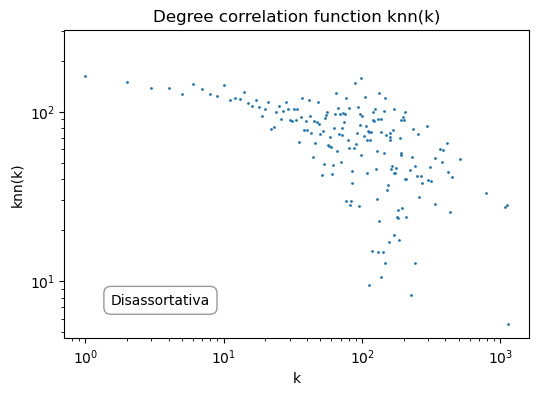

In [105]:
plot_knn(G)

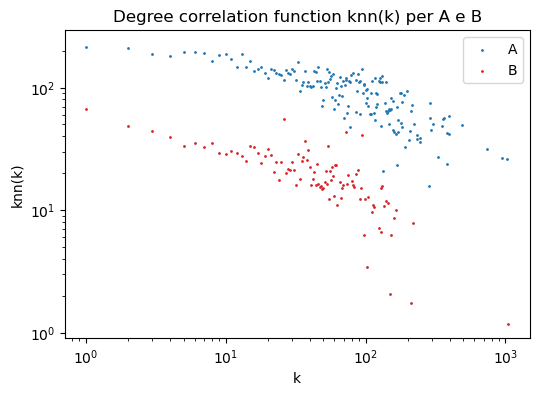

In [ ]:
# plotto per le due comunità A e B separatamente
k_A, knn_A = compute_knn(G_A)
k_B, knn_B = compute_knn(G_B)


fig, ax = plt.subplots(figsize=FIGSIZE, sharex=True, sharey=True)
for k, knn, group, color in zip([k_A, k_B], [knn_A, knn_B], ['A', 'B'], [color_group['A'], color_group['B']]):
    ax.scatter(k, knn, s=1, color=color, label=group)
    ax.set_xscale('log')
    ax.set_yscale('log')  
    ax.set_xlabel("k")
    ax.set_ylabel("knn(k)")  
    ax.set_title("Degree correlation function knn(k) per A e B")
    ax.legend()
plt.show()
plt.close(fig)


In [78]:
r ={
    'Assortatività globale': G.assortativity_degree(directed=False),
    'Assortatività A': G_A.assortativity_degree(directed=False),
    'Assortatività B': G_B.assortativity_degree(directed=False)
}


print(f"Coefficiente di assortatività globale: {r['Assortatività globale']:.4f}")
print(f"Coefficiente di assortatività A: {r['Assortatività A']:.4f}")
print(f"Coefficiente di assortatività B: {r['Assortatività B']:.4f}")


Coefficiente di assortatività globale: -0.1398
Coefficiente di assortatività A: -0.1961
Coefficiente di assortatività B: -0.0988


Se qualcuno vuole farci un fit, che lo faccia lui. io non c'ho voglia